# 01 — RSI & RSI-divergence: the vocabulary

First notebook of a new research line. **No edge claim here** — this is the *"what is it / what does it look like"* step. We (1) define RSI with intuition, (2) draw it over five timeframes on BTCUSDT so you feel how the timeframe changes it, (3) define divergence, and (4) detect & annotate real divergences in the data.

## What RSI is (intuition first)

RSI = **Relative Strength Index** (Welles Wilder, 1978). It answers one question on a 0–100 scale:

> *Over the last ~N bars, how lopsided were the up-moves vs the down-moves?*

Think of a tug-of-war between buyers and sellers over a trailing window. RSI measures **who pulled harder**, not how far price moved.

- **RSI = 50** → up-pressure and down-pressure balanced.
- **RSI → 100** → almost every recent bar closed up (relentless buying) → "overbought".
- **RSI → 0** → almost every recent bar closed down (relentless selling) → "oversold".
- Conventional bands: **70 = overbought**, **30 = oversold**. These are *folklore thresholds*, not laws — we'll test them later.

### The formula (Wilder)

For each bar take the close-to-close change `Δ = close.diff()`. Split it:

- `gain  = max(Δ, 0)`  (up-moves, losses zeroed)
- `loss  = max(-Δ, 0)` (down-moves, gains zeroed)

Smooth each with **Wilder's moving average** (an EWMA with `alpha = 1/N`, default `N=14`):

$$RS = \frac{\text{avg gain}}{\text{avg loss}}, \qquad RSI = 100 - \frac{100}{1 + RS}$$

So RSI is just a *rescaled ratio of average gains to average losses*. If avg gain = avg loss → RS=1 → RSI=50. If there were no down-bars at all → RS=∞ → RSI=100.

**Causality:** RSI[t] uses only closes up to bar `t`. It's a legitimate, non-lookahead feature — unlike a swing pivot (below).

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

SYM = "BTCUSDT"
# A 14-day window: same calendar span shown at every timeframe so we can compare
# how reactive / noisy RSI is as the bar size grows.
W0, W1 = "2025-02-01", "2025-02-15"
px = ohlcv(SYM, W0, W1, "1min")
print(SYM, W0, "->", W1, "| 1m bars:", len(px))
px.tail(3)

BTCUSDT 2025-02-01 -> 2025-02-15 | 1m bars: 20160


,open,high,low,close,volume
timestamp,,,,,
2025-02-14 23:57:00+00:00,97449.9,97468.2,97449.9,97468.2,15.009
2025-02-14 23:58:00+00:00,97468.2,97471.4,97450.8,97458.3,20.296
2025-02-14 23:59:00+00:00,97458.3,97458.3,97450.0,97450.1,9.057


## RSI across timeframes

We have 1-minute data; any higher timeframe is a **resample** (in live trading we'd assemble the same candles from the WS feed). The 2h candle doesn't exist natively on the exchange — we build it. Below: the *same 14 days* at 1m / 15m / 1h / 2h / 4h, RSI(14) on each.

Watch the trade-off: low TF = many bars, RSI whips between extremes (mostly noise); high TF = few bars, RSI is smooth and its 70/30 touches line up with real swing tops/bottoms. **A '4h RSI of 75' and a '1m RSI of 75' are not the same event.**

[saved] notebooks\rsi\_out\01_rsi_multitf.png


WindowsPath('C:/projects/researchlab/notebooks/rsi/_out/01_rsi_multitf.png')

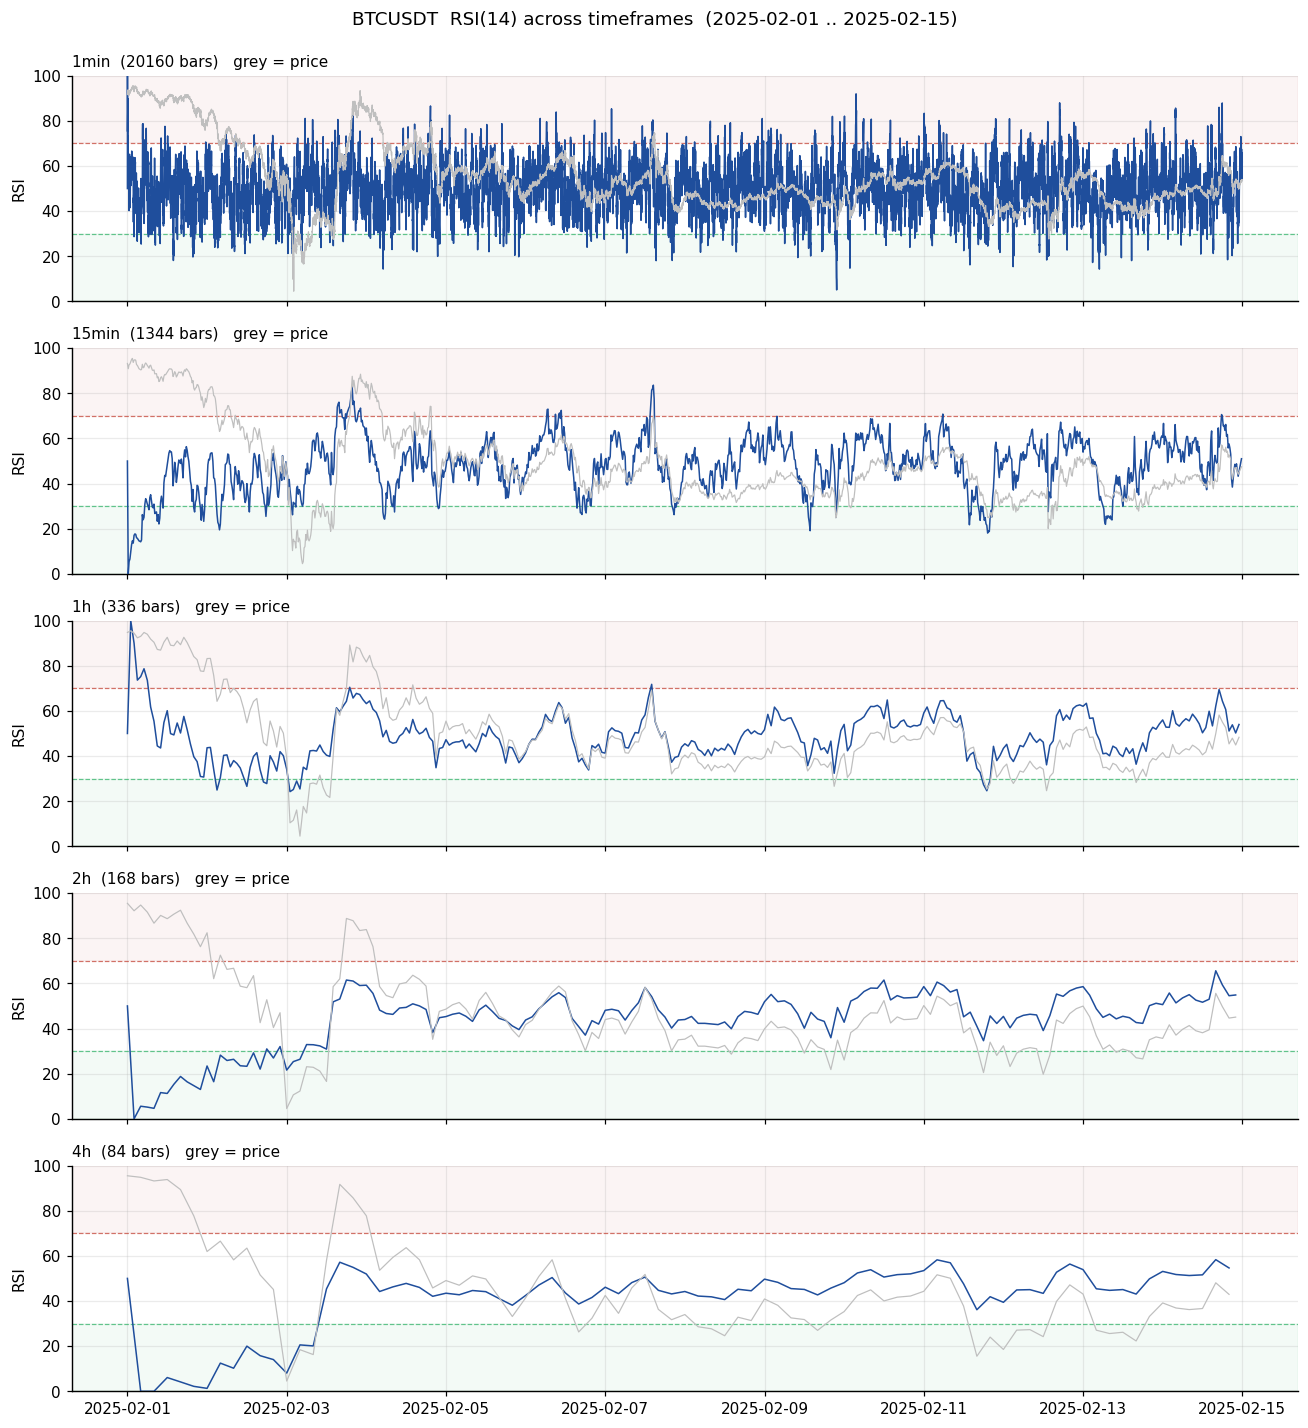

In [2]:
TFS = ["1min", "15min", "1h", "2h", "4h"]
fig, axes = plt.subplots(len(TFS), 1, figsize=(12, 13), sharex=True)
for ax, tf in zip(axes, TFS):
    d = ohlcv(SYM, W0, W1, tf)
    r = rsi(d["close"], 14)
    # price faint on a twin axis so we can see RSI extremes vs price swings
    axp = ax.twinx()
    axp.plot(d.index, d["close"], color="0.75", lw=0.8, zorder=1)
    axp.set_yticks([]); axp.grid(False)
    ax.plot(d.index, r, color="#1f4e9c", lw=1.0, zorder=3)
    ax.axhline(70, color="#c0392b", lw=0.8, ls="--", alpha=0.7)
    ax.axhline(30, color="#27ae60", lw=0.8, ls="--", alpha=0.7)
    ax.axhspan(70, 100, color="#c0392b", alpha=0.05)
    ax.axhspan(0, 30, color="#27ae60", alpha=0.05)
    ax.set_ylim(0, 100); ax.set_ylabel("RSI")
    ax.set_title(f"{tf}  ({len(d)} bars)   grey = price", loc="left", fontsize=10)
fig.suptitle(f"{SYM}  RSI(14) across timeframes  ({W0} .. {W1})", y=0.995)
show("01_rsi_multitf")

## What a divergence is

A **divergence** is when **price and RSI disagree about a trend** at two consecutive swing points. The idea: price made a new extreme, but the *momentum behind it* (RSI) did not confirm — the move is running on fumes.

There are four named cases. The two **regular** ones (reversal signals) are what we detect here:

| Type | Price does | RSI does | Story |
|---|---|---|---|
| **Regular bearish** | Higher High | **Lower** High | new price top, weaker momentum → possible **top / short** |
| **Regular bullish** | Lower Low | **Higher** Low | new price bottom, less selling force → possible **bottom / long** |
| Hidden bearish | Lower High | Higher High | trend-continuation (down) |
| Hidden bullish | Higher Low | Lower Low | trend-continuation (up) |

**How we find the swings — and the lookahead landmine.** A divergence needs two *swing pivots*. A swing high at bar `i` is only a swing high if the `k` bars after it are lower — so it can only be **confirmed at bar `i+k`**, never at `i`. Drawing pivots in hindsight (as we do below, for illustration) silently uses the future. This is the exact anchor-lookahead that turned the pump line's +77% into a loss and closed the levels line. So: **today we only *look*; any future edge claim must enter at `i+k` or later.** `pivots()` in `_lab.py` enforces the `k`-bar window.

In [3]:
def find_divergences(d, k=5, rsi_n=14, max_gap=60, min_gap=5):
    """Regular bullish/bearish RSI divergences between adjacent confirmed pivots.

    Pivots are causal (confirmed k bars late). Returns two lists of dicts with
    integer positions (i1,i2) of the two swings. Descriptive only — entries, if
    ever traded, must be placed at i2+k (confirmation), not at i2.
    """
    r = rsi(d["close"], rsi_n)
    hi, lo = pivots(d["close"], k)
    H, L, R = d["high"].to_numpy(), d["low"].to_numpy(), r.to_numpy()
    bear, bull = [], []
    for a, b in zip(hi[:-1], hi[1:]):              # adjacent swing highs
        if min_gap <= (b - a) <= max_gap and H[b] > H[a] and R[b] < R[a]:
            bear.append(dict(i1=a, i2=b))
    for a, b in zip(lo[:-1], lo[1:]):              # adjacent swing lows
        if min_gap <= (b - a) <= max_gap and L[b] < L[a] and R[b] > R[a]:
            bull.append(dict(i1=a, i2=b))
    return bear, bull, r

# Detect on 1h over a few months where trends turn (plenty of swings).
DW0, DW1, DTF = "2025-01-01", "2025-05-01", "1h"
dd = ohlcv(SYM, DW0, DW1, DTF)
bear, bull, r = find_divergences(dd, k=6, max_gap=72)
print(f"{SYM} {DTF} {DW0}..{DW1}: {len(dd)} bars")
print(f"regular BEARISH divergences: {len(bear)}")
print(f"regular BULLISH divergences: {len(bull)}")

BTCUSDT 1h 2025-01-01..2025-05-01: 2880 bars
regular BEARISH divergences: 12
regular BULLISH divergences: 14


### Drawing the detected divergences

Two stacked panels share the time axis: **price on top, RSI below**. For each divergence we draw the connecting line on *both* panels — they slope opposite ways, which is the whole point. Red = bearish (price up-slope, RSI down-slope). Green = bullish (price down-slope, RSI up-slope).

[saved] notebooks\rsi\_out\01_divergence_1h.png


WindowsPath('C:/projects/researchlab/notebooks/rsi/_out/01_divergence_1h.png')

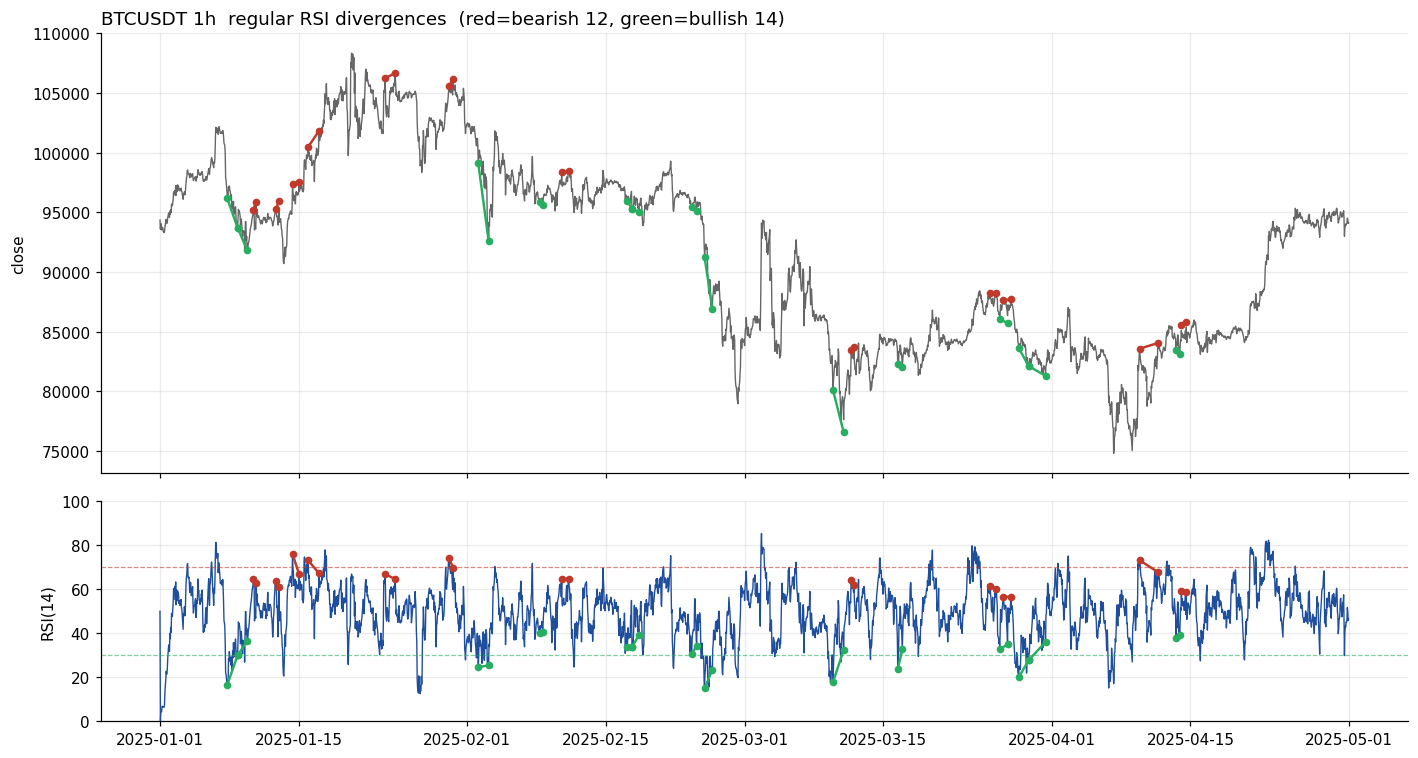

In [4]:
fig, (axp, axr) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
t = dd.index
axp.plot(t, dd["close"], color="0.4", lw=0.9)
axr.plot(t, r, color="#1f4e9c", lw=0.9)
axr.axhline(70, color="#c0392b", lw=0.8, ls="--", alpha=0.6)
axr.axhline(30, color="#27ae60", lw=0.8, ls="--", alpha=0.6)
axr.set_ylim(0, 100); axr.set_ylabel("RSI(14)"); axp.set_ylabel("close")

def draw(divs, color, price_key):
    pk = dd[price_key].to_numpy()
    for d_ in divs:
        i1, i2 = d_["i1"], d_["i2"]
        axp.plot([t[i1], t[i2]], [pk[i1], pk[i2]], color=color, lw=1.6, marker="o", ms=4)
        axr.plot([t[i1], t[i2]], [r.iloc[i1], r.iloc[i2]], color=color, lw=1.6, marker="o", ms=4)

draw(bear, "#c0392b", "high")
draw(bull, "#27ae60", "low")
axp.set_title(f"{SYM} {DTF}  regular RSI divergences  (red=bearish {len(bear)}, green=bullish {len(bull)})",
              loc="left")
show("01_divergence_1h")

## Read-out & honest caveats

*(filled in after execution, in the chat reply.)*

**What we have NOT done yet (on purpose):**
- **No edge measured.** We only *located* divergences. Whether shorting a bearish / longing a bullish divergence beats a baseline — and survives the `i+k` confirmation lag + ~0.1–0.2% costs — is the next notebook.
- **Pivots are drawn in hindsight.** The connecting lines end at a confirmed swing `i2`, knowable only at `i2+k`. Any tradeable test must shift the decision to `i2+k`.
- **One symbol, one period, one parameter set** (`k`, `max_gap`, RSI=14). Divergence *counts* are sensitive to these knobs — pooling and parameter robustness come later.
- **No filtering by quality** (overbought level at the pivot, slope steepness, trend context). All adjacent-pivot HH/LH (and LL/HL) pairs are shown raw.

**Next step (proposed):** measure the *baseline-relative* forward return after a confirmed bearish/bullish divergence (enter at `i2+k`, exit at fixed horizons), pooled across many symbols — the same event-study frame that worked for dump. State it as a prediction before running.